In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

from langchain_groq import ChatGroq

# os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="llama-3.3-70b-versatile")

# llm = ChatOpenAI(model="gpt-4o")

result = llm.invoke("Hello")

result

AIMessage(content='Hello. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 36, 'total_tokens': 46, 'completion_time': 0.031827987, 'completion_tokens_details': None, 'prompt_time': 0.003212194, 'prompt_tokens_details': None, 'queue_time': 0.049782235, 'total_time': 0.035040181}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ea593-658a-7523-9a67-1944103f41cd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 10, 'total_tokens': 46})

In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END 

from IPython.display import Image,display

## Graph state
class State(TypedDict):
    topic:str
    characters:str
    settings:str 
    premises:str 
    story_intro:str

In [3]:
# Nodes
def generate_characters(state: State):
    """Generate character descriptions"""
    msg = llm.invoke(
        f"Create two character names and brief traits for a story about {state['topic']}"
    )
    return {"characters": msg.content}

def generate_setting(state: State):
    """Generate a story setting"""
    msg = llm.invoke(
        f"Describe a vivid setting for a story about {state['topic']}"
    )
    return {"settings": msg.content}


def generate_premise(state: State):
    """Generate a story premise"""
    msg = llm.invoke(
        f"Write a one-sentence plot premise for a story about {state['topic']}"
    )
    return {"premises": msg.content}

def combine_elements(state: State):
    """Combine characters, setting, and premise into an intro"""
    
    msg = llm.invoke(
        f"Write a short story introduction using these elements:\n"
        f"Characters: {state['characters']}\n"
        f"Setting: {state['settings']}\n"
        f"Premise: {state['premises']}"
    )

    return {"story_intro": msg.content}

In [4]:
# Build the graph
graph = StateGraph(State)

graph.add_node("character", generate_characters)
graph.add_node("setting", generate_setting)
graph.add_node("premise", generate_premise)
graph.add_node("combine", combine_elements)

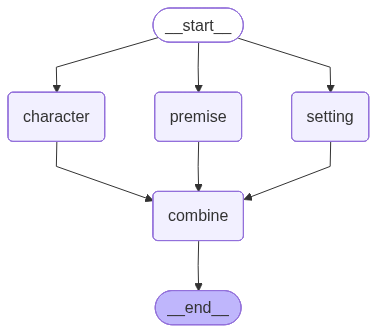

In [5]:
# Define edges (parallel execution from START)

graph.add_edge(START, "character")
graph.add_edge(START, "setting")
graph.add_edge(START, "premise")

graph.add_edge("character", "combine")
graph.add_edge("setting", "combine")
graph.add_edge("premise", "combine")

graph.add_edge("combine", END)

# Compile and run

compiled_graph = graph.compile()

graph_image = compiled_graph.get_graph().draw_mermaid_png()

display(Image(graph_image))

In [6]:
state = {"topic": "time travel"}

result = compiled_graph.invoke(state)

print(result["story_intro"])

As the last wisps of sunlight disappeared from the forgotten alleyway, Evelyn "Evie" Thompson stood before the unassuming door with a mix of excitement and trepidation. The worn, brass doorknob in the shape of a serpent devouring its own tail seemed to gleam in the fading light, as if beckoning her towards the unknown. With a deep breath, she reached out and grasped the doorknob, feeling an inexplicable jolt of energy run through her veins. This was it – the moment she had spent her entire life working towards. Her time machine, the culmination of years of tireless research and experimentation, was finally ready to be tested.

Just as Evie was about to turn the doorknob, a figure emerged from the shadows. James "Hawk" Hawkins, the charismatic ex-military officer recruited by a secret organization to aid her in her mission, stepped forward with a confident smile. His piercing eyes seemed to bore into her very soul, as if searching for any hint of uncertainty. "Ready to change the course

## Key Benefits

* **Speed:** Reduces total execution time by running tasks concurrently.

* **Scalability:** Handles larger workflows efficiently.

* **Modularity:** Keeps the graph structure clean and reusable.

## Key Takeaways

* **When to Parallelize:** Use it for independent tasks (e.g., generating multiple outputs, checking separate inputs).

* **Merging:** Downstream nodes can aggregate parallel results.

* **LangGraph Support:** The framework naturally supports this by waiting for all required inputs before proceeding.
